In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("/content/gender_classification.csv")

In [5]:
df

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [6]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64


In [7]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 1768


In [8]:
df = df.drop_duplicates()

In [9]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [10]:
from sklearn.preprocessing import LabelEncoder #sklearn is used for ML #labelencoding used because Machine cannot read text files


In [11]:
# Encode gender (Male=1, Female=0)
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])

/tmp/ipykernel_8763/1105618088.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["gender"] = le.fit_transform(df["gender"])


In [12]:
X = df.drop("gender", axis=1) #male=0,female=1, axis=0(rows),axis=1(columns) #this command is used for only display first 7 columns, its avoided gender column
y = df["gender"] # its show only gender column

In [13]:
from sklearn.model_selection import train_test_split # this is splitting the data, 70 part of data is given to machine for training the data and 30 part of data is use for test to machine how much studied.

In [14]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [17]:
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression
y_pred_log = log_reg.predict(X_test)
print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=["Female","Male"]))


Logistic Regression Results
Accuracy: 0.9556701030927836
              precision    recall  f1-score   support

      Female       0.96      0.95      0.95       457
        Male       0.96      0.96      0.96       513

    accuracy                           0.96       970
   macro avg       0.96      0.96      0.96       970
weighted avg       0.96      0.96      0.96       970



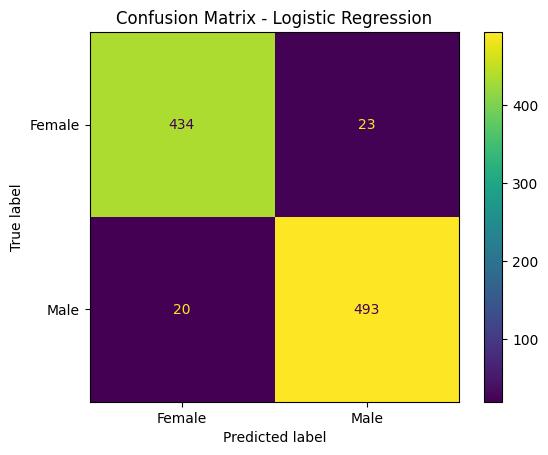

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Female", "Male"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [19]:
#External Prediction
# ------------------------------
new_data = [[0, 13.5, 6.2, 1, 1, 0, 1]]  # Example new input

# Column names must match training data
new_data_df = pd.DataFrame(new_data, columns=X.columns)

# Predict again
log_result = log_reg.predict(new_data_df)[0]


print("Logistic Regression:", le.inverse_transform([log_result])[0])

Logistic Regression: Male


TITANIC DATASET

In [20]:
import pandas as pd

In [21]:
df=pd.read_csv("/content/titanic.csv")

In [22]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [23]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [25]:
df['Age']= df['Age'].fillna('')

In [26]:
df['Cabin']= df['Cabin'].fillna('')

In [27]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [28]:
df['Embarked']= df['Embarked'].fillna('')

In [29]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [33]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

In [36]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,,S
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,,1,2,W./C. 6607,23.4500,,S
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C


In [56]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,,3
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,,3
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,3
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,,1,2,W./C. 6607,23.4500,,3
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,1


In [58]:
df=df.drop(columns=['PassengerId','Name','Ticket','Cabin','Embarked','Fare']).fillna('')

In [60]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,1,22.0,1,0
1,1,1,0,38.0,1,0
2,1,3,0,26.0,0,0
3,1,1,0,35.0,1,0
4,0,3,1,35.0,0,0
...,...,...,...,...,...,...
886,0,2,1,27.0,0,0
887,1,1,0,19.0,0,0
888,0,3,0,,1,2
889,1,1,1,26.0,0,0


In [76]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [77]:
from sklearn.model_selection import train_test_split

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
import numpy as np
import pandas as pd

# Make a copy to avoid modifying the original X_train directly
X_train_processed = X_train.copy()

# Convert empty strings to NaN in the 'Age' column
X_train_processed['Age'] = X_train_processed['Age'].replace('', np.nan)

# Convert the 'Age' column to numeric, coercing any remaining errors to NaN
X_train_processed['Age'] = pd.to_numeric(X_train_processed['Age'], errors='coerce')

# Impute NaN values in 'Age' with the mean of the 'Age' column
mean_age = X_train_processed['Age'].mean()
X_train_processed['Age'] = X_train_processed['Age'].fillna(mean_age)

# Initialize and fit the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_processed, y_train)

/tmp/ipykernel_8763/2815222141.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_processed['Age'] = X_train_processed['Age'].replace('', np.nan)


LogisticRegression(max_iter=1000)

In [99]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd

# Make a copy of X_test for preprocessing
X_test_processed = X_test.copy()

# Convert empty strings to NaN in the 'Age' column
X_test_processed['Age'] = X_test_processed['Age'].replace('', np.nan)

# Convert the 'Age' column to numeric, coercing any remaining errors to NaN
X_test_processed['Age'] = pd.to_numeric(X_test_processed['Age'], errors='coerce')

# Impute NaN values in 'Age' with the mean calculated from X_train_processed
# Ensure mean_age is available from the training preprocessing step
X_test_processed['Age'] = X_test_processed['Age'].fillna(mean_age)

y_pred_log = log_reg.predict(X_test_processed)
print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=["Survived","Not Survived"]))


Logistic Regression Results
Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

    Survived       0.83      0.86      0.85       105
Not Survived       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



/tmp/ipykernel_8763/2455048090.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_processed['Age'] = X_test_processed['Age'].replace('', np.nan)


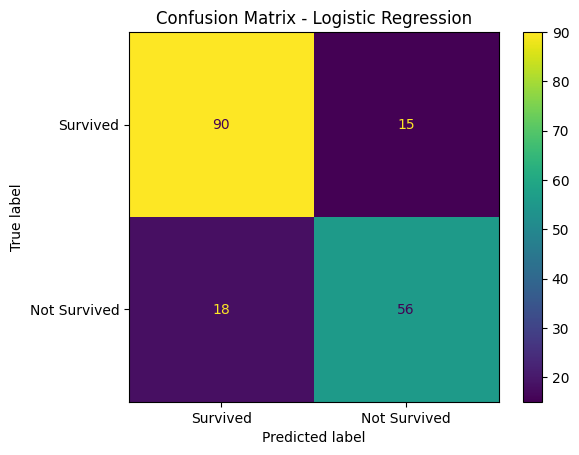

In [103]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survived","Not Survived"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [104]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,1,22.0,1,0
1,1,1,0,38.0,1,0
2,1,3,0,26.0,0,0
3,1,1,0,35.0,1,0
4,0,3,1,35.0,0,0
...,...,...,...,...,...,...
886,0,2,1,27.0,0,0
887,1,1,0,19.0,0,0
888,0,3,0,,1,2
889,1,1,1,26.0,0,0


In [113]:
new_data=[[3,0,26,0,0]]
new_data_df = pd.DataFrame(new_data, columns=X.columns)
log_result = log_reg.predict(new_data_df)[0]

print("Logistic Regression:", le.inverse_transform([log_result])[0])

Logistic Regression: 1
